# Lab 4: Markov Chain and Q-Learning

## Objective

To understand the concepts of Markov Chains and Markov Decision Processes (MDP), and to implement the Q-Learning algorithm so that an agent can learn an optimal policy to navigate a grid-world environment from a start state to a goal state while avoiding obstacles, using a reward-based update rule.

---

## 1. Theory

### 1.1 Markov Chain

A **Markov Chain** is a mathematical model that describes a system which transitions from one state to another among a finite (or countable) set of possible states. The defining property of a Markov Chain is the **Markov Property**, which states that the probability of moving to the next state depends *only* on the current state, and not on the sequence of states that preceded it.

Formally, for a sequence of states \(S_0, S_1, S_2, \dots\):

$$
P(S_{t+1} \mid S_t, S_{t-1}, \dots, S_0) = P(S_{t+1} \mid S_t)
$$

This "memoryless" property makes Markov Chains a powerful tool for modeling systems where the future state depends only on the present state.

### 1.2 Markov Decision Process (MDP)

A **Markov Decision Process** extends the Markov Chain by introducing **actions** and **rewards**, which allows an agent to make decisions rather than just observe random transitions. An MDP is formally defined as a tuple:

$$
MDP = (S, A, P, R, \gamma)
$$

Where:
- **S** — a finite set of states (e.g., grid cells S0 to S15)
- **A** — a finite set of actions (Up, Down, Left, Right)
- **P** — the state transition probability, \(P(s' \mid s, a)\)
- **R** — the reward function, \(R(s, a, s')\)
- **γ (gamma)** — the discount factor, which determines how much future rewards are valued compared to immediate rewards

The goal of an MDP is to find a **policy** \( \pi(s) \) — a mapping from states to actions — that maximizes the expected cumulative (discounted) reward over time.

### 1.3 Q-Learning

**Q-Learning** is a model-free, off-policy reinforcement learning algorithm used to find the optimal action-selection policy for a given MDP. It does not require knowledge of the transition probabilities \(P\) — the agent learns purely through trial and error by interacting with the environment.

The algorithm maintains a **Q-table**, which stores a Q-value \(Q(s, a)\) for every state-action pair. This value represents the expected utility of taking action \(a\) in state \(s\) and following the optimal policy thereafter.

#### Q-Learning Update Equation

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \Big[ R + \gamma \max_{a'} Q(s', a') - Q(s, a) \Big]
$$

**Explanation of terms:**

| Symbol | Meaning |
|---|---|
| \(Q(s, a)\) | Current estimated value of taking action \(a\) in state \(s\) |
| \(\alpha\) | Learning rate — controls how much new information overrides old information |
| \(R\) | Immediate reward received after taking action \(a\) in state \(s\) |
| \(\gamma\) | Discount factor — controls the importance of future rewards |
| \(\max_{a'} Q(s', a')\) | The maximum estimated Q-value achievable from the next state \(s'\), over all possible next actions \(a'\) |
| \(R + \gamma \max_{a'} Q(s', a') - Q(s, a)\) | The **temporal difference (TD) error** — the difference between the predicted and the "better estimated" value |

In simple terms, after every action, the agent updates its belief about how good that action was by combining:
1. What it already believed (old Q-value),
2. What reward it actually received, and
3. What it now expects to gain in the future from the new state.

Over many episodes of exploration, the Q-values converge to their true optimal values, and the agent can then always choose the action with the highest Q-value in any state to behave optimally.

### 1.4 Advantages of Q-Learning

- **Model-free**: Does not require prior knowledge of the environment's transition probabilities or reward function.
- **Off-policy learning**: Can learn the optimal policy even while following a different (e.g., exploratory) policy.
- **Guaranteed convergence**: Under suitable conditions (all state-action pairs visited infinitely often, appropriately decaying learning rate), Q-Learning is guaranteed to converge to the optimal Q-values.
- **Simplicity**: Easy to implement using a simple lookup table for small/discrete state spaces.
- **Flexibility**: Can be combined with function approximators (e.g., neural networks) to scale to large or continuous state spaces (Deep Q-Learning).

### 1.5 Disadvantages of Q-Learning

- **Scalability issue**: The Q-table grows exponentially with the number of states and actions, making it impractical for large or continuous state spaces without approximation.
- **Slow convergence**: May require a very large number of episodes/iterations to converge, especially in large environments.
- **Exploration vs. Exploitation trade-off**: Choosing how much to explore versus exploit is non-trivial and directly affects learning efficiency.
- **Memory intensive**: Storing a Q-value for every state-action pair can consume significant memory.
- **Sensitive to hyperparameters**: Performance heavily depends on the choice of learning rate (α), discount factor (γ), and exploration strategy (e.g., ε-greedy).

---

## 2. Problem Setup (Grid World)

The lab uses a **4×4 grid world** with 16 states labeled S0 to S15, arranged as follows:

| | | | |
|---|---|---|---|
| S0 (Start) | S1 | S2 | S3 |
| S4 | S5 (Obstacle) | S6 | S7 |
| S8 | S9 | S10 (Obstacle) | S11 |
| S12 | S13 | S14 | S15 (Goal) |

**Environment parameters:**

- **Actions available**: Up, Down, Left, Right
- **Start state**: S0
- **Goal state**: S15
- **Obstacle states**: S5 and S10 (agent cannot pass through / gets penalized)
- **Learning rate (α)**: 0.5
- **Discount factor (γ)**: 0.9

**Reward structure:**

| Event | Reward |
|---|---|
| Reaching Goal state (S15) | +10 |
| Hitting an Obstacle (S5, S10) | −10 |
| Normal move (any other transition) | −1 |

The agent starts at S0 and, through repeated episodes of trial and error, updates its Q-table using the Q-learning update rule until it learns the shortest, safest path to the goal while avoiding the obstacle cells.

---

### Code 

Training completed over 500 episodes.

Q-Table (state x action):
State   Up        Down      Left      Right     
------------------------------------------------
S0      0.63      -0.43     0.63      1.81      
S1      1.81      -10.00    0.63      3.12      
S2      3.12      4.58      1.81      4.58      
S3      4.58      6.20      3.12      4.58      
S4      0.63      -1.23     -1.54     -9.69     
S5      0.00      0.00      0.00      0.00      
S6      1.90      -9.69     -9.38     6.20      
S7      4.58      8.00      4.58      6.20      
S8      -2.08     1.70      -1.85     -2.00     
S9      -5.00     0.37      -1.49     -5.00     
S10     0.00      0.00      0.00      0.00      
S11     6.20      10.00     -10.00    8.00      
S12     -1.69     -1.65     -1.43     4.96      
S13     -1.13     1.35      -1.30     7.68      
S14     -5.00     -0.50     -0.72     9.96      
S15     0.00      0.00      0.00      0.00      


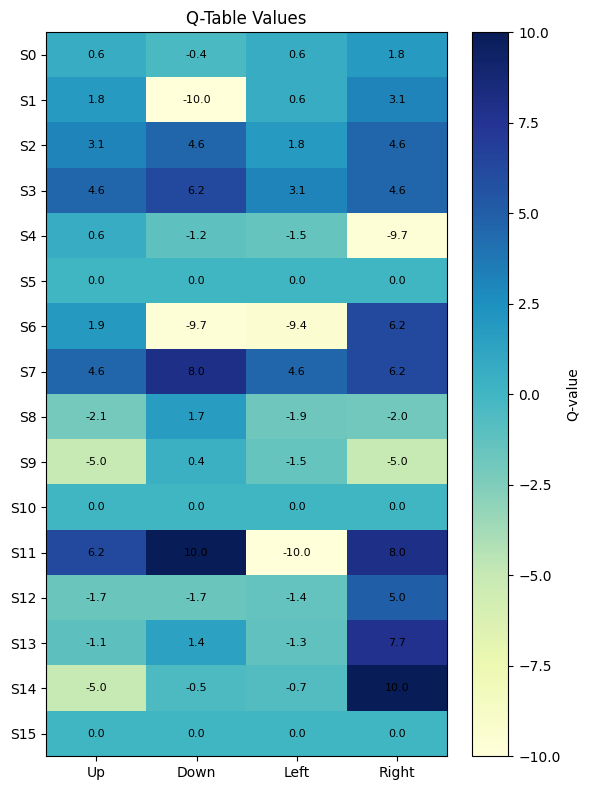


Learned greedy path from Start (S0) to Goal (S15):
S0 -> S1 -> S2 -> S3 -> S7 -> S11 -> S15


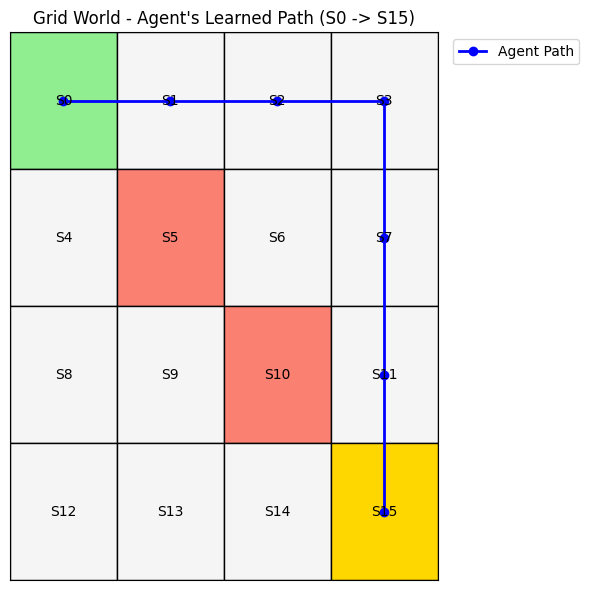

In [1]:
"""
Lab 4: Markov Chain & Q-Learning
---------------------------------
Grid World Q-Learning Implementation

Grid layout (4x4):
    S0  S1  S2  S3
    S4  S5* S6  S7        (S5 = Obstacle)
    S8  S9  S10* S11      (S10 = Obstacle)
    S12 S13 S14 S15(Goal)

Actions: Up, Down, Left, Right
Rewards: Goal = +10 | Obstacle = -10 | Normal move = -1
alpha (learning rate) = 0.5
gamma (discount factor) = 0.9
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

# -----------------------------
# 1. Environment Setup
# -----------------------------
GRID_SIZE = 4
N_STATES = GRID_SIZE * GRID_SIZE
START_STATE = 0
GOAL_STATE = 15
OBSTACLES = [5, 10]

ACTIONS = ["Up", "Down", "Left", "Right"]
N_ACTIONS = len(ACTIONS)

ALPHA = 0.5     # Learning rate
GAMMA = 0.9     # Discount factor
EPSILON = 0.2   # Exploration rate (epsilon-greedy)
EPISODES = 500
MAX_STEPS = 100

REWARD_GOAL = 10
REWARD_OBSTACLE = -10
REWARD_MOVE = -1

# Q-table: rows = states (S0..S15), columns = actions (Up, Down, Left, Right)
Q = np.zeros((N_STATES, N_ACTIONS))


def state_to_rc(state):
    """Convert state index to (row, col) on the grid."""
    return divmod(state, GRID_SIZE)


def rc_to_state(row, col):
    """Convert (row, col) back to a state index."""
    return row * GRID_SIZE + col


def get_next_state(state, action):
    """
    Return the next state given the current state and action.
    If the action would move the agent off the grid, the agent stays in place.
    """
    row, col = state_to_rc(state)

    if action == "Up":
        row = max(row - 1, 0)
    elif action == "Down":
        row = min(row + 1, GRID_SIZE - 1)
    elif action == "Left":
        col = max(col - 1, 0)
    elif action == "Right":
        col = min(col + 1, GRID_SIZE - 1)

    return rc_to_state(row, col)


def get_reward(next_state):
    """Return the reward for landing on next_state."""
    if next_state == GOAL_STATE:
        return REWARD_GOAL
    elif next_state in OBSTACLES:
        return REWARD_OBSTACLE
    else:
        return REWARD_MOVE


def choose_action(state):
    """Epsilon-greedy action selection."""
    if random.uniform(0, 1) < EPSILON:
        return random.randint(0, N_ACTIONS - 1)   # Explore
    else:
        return int(np.argmax(Q[state]))            # Exploit


# -----------------------------
# 2. Q-Learning Training Loop
# -----------------------------
def train():
    for episode in range(EPISODES):
        state = START_STATE
        steps = 0
        done = False

        while not done and steps < MAX_STEPS:
            action_idx = choose_action(state)
            action = ACTIONS[action_idx]

            next_state = get_next_state(state, action)
            reward = get_reward(next_state)

            # Q-Learning update rule:
            # Q(s,a) = Q(s,a) + alpha * [R + gamma * max(Q(s',a')) - Q(s,a)]
            best_next_q = np.max(Q[next_state])
            Q[state, action_idx] += ALPHA * (
                reward + GAMMA * best_next_q - Q[state, action_idx]
            )

            # Episode ends if agent reaches the goal or hits an obstacle
            if next_state == GOAL_STATE or next_state in OBSTACLES:
                done = True

            state = next_state
            steps += 1

    print(f"Training completed over {EPISODES} episodes.\n")


# -----------------------------
# 3. Display the Q-Table
# -----------------------------
def display_q_table():
    print("Q-Table (state x action):")
    header = f"{'State':<8}" + "".join(f"{a:<10}" for a in ACTIONS)
    print(header)
    print("-" * len(header))
    for s in range(N_STATES):
        row = f"S{s:<7}" + "".join(f"{Q[s, a]:<10.2f}" for a in range(N_ACTIONS))
        print(row)


def plot_q_table():
    """Display the Q-table as a heatmap-style figure."""
    fig, ax = plt.subplots(figsize=(6, 8))
    im = ax.imshow(Q, cmap="YlGnBu", aspect="auto")

    ax.set_xticks(range(N_ACTIONS))
    ax.set_xticklabels(ACTIONS)
    ax.set_yticks(range(N_STATES))
    ax.set_yticklabels([f"S{s}" for s in range(N_STATES)])
    ax.set_title("Q-Table Values")

    for s in range(N_STATES):
        for a in range(N_ACTIONS):
            ax.text(a, s, f"{Q[s, a]:.1f}", ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax, label="Q-value")
    plt.tight_layout()
    plt.savefig("q_table.png", dpi=150)
    plt.show()


# -----------------------------
# 4. Display the Grid & Agent Path
# -----------------------------
def get_greedy_path():
    """Follow the learned (greedy) policy from start to goal."""
    path = [START_STATE]
    state = START_STATE
    visited = set()

    for _ in range(MAX_STEPS):
        if state == GOAL_STATE or state in visited:
            break
        visited.add(state)
        action_idx = int(np.argmax(Q[state]))
        next_state = get_next_state(state, ACTIONS[action_idx])
        path.append(next_state)
        if next_state in OBSTACLES:
            break
        state = next_state

    return path


def plot_grid_and_agent(path):
    """Draw the grid world, obstacles, goal, and the agent's learned path."""
    fig, ax = plt.subplots(figsize=(6, 6))

    for s in range(N_STATES):
        row, col = state_to_rc(s)
        x, y = col, GRID_SIZE - 1 - row  # flip row for correct plotting orientation

        if s == START_STATE:
            color = "lightgreen"
        elif s == GOAL_STATE:
            color = "gold"
        elif s in OBSTACLES:
            color = "salmon"
        else:
            color = "whitesmoke"

        rect = patches.Rectangle((x, y), 1, 1, facecolor=color, edgecolor="black")
        ax.add_patch(rect)
        ax.text(x + 0.5, y + 0.5, f"S{s}", ha="center", va="center", fontsize=10)

    # Draw the agent's learned path
    xs, ys = [], []
    for s in path:
        row, col = state_to_rc(s)
        xs.append(col + 0.5)
        ys.append(GRID_SIZE - 1 - row + 0.5)
    ax.plot(xs, ys, marker="o", color="blue", linewidth=2, label="Agent Path")

    ax.set_xlim(0, GRID_SIZE)
    ax.set_ylim(0, GRID_SIZE)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("Grid World - Agent's Learned Path (S0 -> S15)")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.savefig("agent_path.png", dpi=150)
    plt.show()


# -----------------------------
# 5. Main
# -----------------------------
if __name__ == "__main__":
    train()
    display_q_table()
    plot_q_table()

    path = get_greedy_path()
    print("\nLearned greedy path from Start (S0) to Goal (S15):")
    print(" -> ".join(f"S{s}" for s in path))

    plot_grid_and_agent(path)

## 3. Discussion

In this lab, we explored the transition from a purely probabilistic model (Markov Chain) to a decision-making framework (MDP), and finally to a practical, model-free learning algorithm (Q-Learning) that solves the MDP without knowing the environment's dynamics in advance.

The grid-world experiment demonstrated how an agent, starting with no knowledge of the environment (Q-table initialized to all zeros), can learn purely from the consequences of its actions — the rewards and penalties it receives. Initially, the agent's movements are essentially random, and it frequently collides with the obstacle states (S5, S10), receiving the penalty of −10. Over successive episodes, the negative reward from these unproductive moves teaches the agent to avoid them, while the positive reward of +10 for reaching S15 reinforces the pathways that lead to the goal.

The learning rate (α = 0.5) determines how aggressively the Q-table is updated with each new experience  a higher value means the agent gives more weight to newly observed rewards over old estimates. The discount factor (γ = 0.9), being close to 1, means the agent strongly values future rewards, encouraging it to plan ahead toward the distant goal state rather than being short-sighted and only considering the immediate reward.

## 4. Conclusion

This lab helped us understand how Markov Chains, MDPs, and Q-Learning work together to enable an agent to make optimal decisions in an uncertain environment. By implementing Q-Learning on a 4×4 grid world, we saw how an agent starting with no prior knowledge could learn, purely through trial and reward feedback, to avoid obstacles at S5 and S10 and find an efficient path from the start state S0 to the goal state S15. The experiment reinforced the importance of the learning rate (α) and discount factor (γ) in balancing how quickly the agent learns versus how much it values long-term rewards, and demonstrated why Q-Learning remains a foundational algorithm in reinforcement learning.